In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIG_DIR = "../results/figures"
TABLE_DIR = "../results/tables"

os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

## Load results

In [2]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

gru_metrics = load_json(f"{TABLE_DIR}/gru_metrics.json")
cnn_metrics = load_json(f"{TABLE_DIR}/cnn_metrics.json")

gru_history = pd.read_csv(f"{TABLE_DIR}/gru_training_history.csv")
cnn_history = pd.read_csv(f"{TABLE_DIR}/cnn_training_history.csv")

gru_metrics, cnn_metrics

({'model': 'GRU_LM',
  'vocab_size': 3906,
  'embedding_dim': 64,
  'hidden_dim': 128,
  'num_layers': 1,
  'dropout': 0.1,
  'batch_size': 16,
  'lr': 0.001,
  'epochs': 3,
  'best_val_loss': 4.019110696792603,
  'test_loss': 4.030971662521362,
  'test_perplexity': 56.31560443336087,
  'test_switch_accuracy': 0.7478090575275398},
 {'model': 'CNN_LM',
  'vocab_size': 3906,
  'embedding_dim': 64,
  'hidden_dim': 128,
  'num_layers': 3,
  'dropout': 0.1,
  'batch_size': 16,
  'lr': 0.001,
  'epochs': 3,
  'best_val_loss': 4.238120712280273,
  'test_loss': 4.2374485473632815,
  'test_perplexity': 69.23098671960751,
  'test_switch_accuracy': 0.7477600979192166})

## Create comparison table

In [3]:
comparison_df = pd.DataFrame([
    {
        "Model": "GRU LM",
        "Test Loss": gru_metrics["test_loss"],
        "Test Perplexity": gru_metrics["test_perplexity"],
        "Switch Accuracy": gru_metrics["test_switch_accuracy"],
        "Embedding Dim": gru_metrics["embedding_dim"],
        "Hidden Dim": gru_metrics["hidden_dim"],
        "Layers": gru_metrics["num_layers"],
    },
    {
        "Model": "CNN LM",
        "Test Loss": cnn_metrics["test_loss"],
        "Test Perplexity": cnn_metrics["test_perplexity"],
        "Switch Accuracy": cnn_metrics["test_switch_accuracy"],
        "Embedding Dim": cnn_metrics["embedding_dim"],
        "Hidden Dim": cnn_metrics["hidden_dim"],
        "Layers": cnn_metrics["num_layers"],
    }
])

comparison_df

,Model,Test Loss,Test Perplexity,Switch Accuracy,Embedding Dim,Hidden Dim,Layers
0,GRU LM,4.030972,56.315604,0.747809,64,128,1
1,CNN LM,4.237449,69.230987,0.747760,64,128,3


In [4]:
comparison_df.to_csv(f"{TABLE_DIR}/model_comparison.csv", index=False)

## Plot 1 - Final test perplexity bar chart

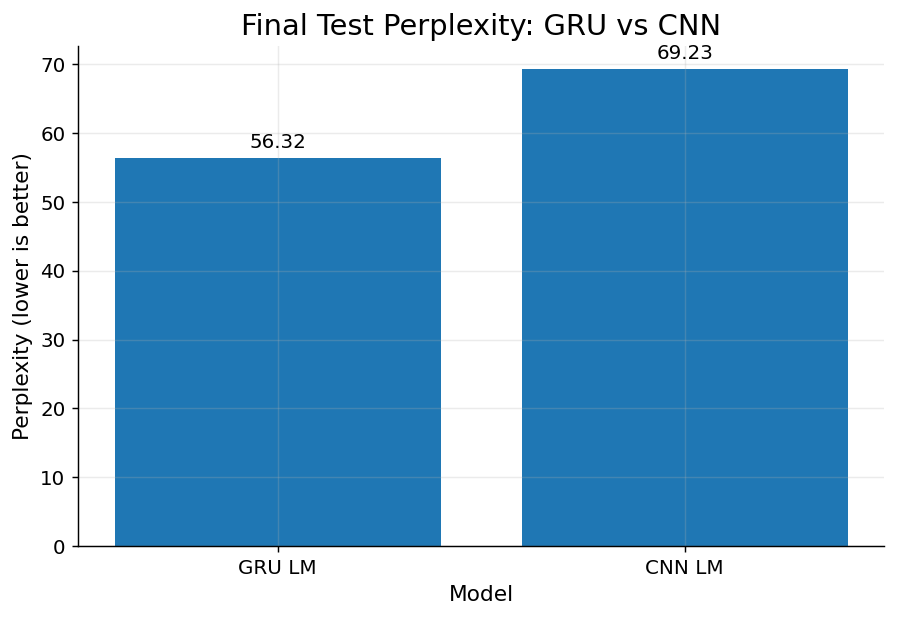

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

models = comparison_df["Model"]
values = comparison_df["Test Perplexity"]

bars = ax.bar(models, values)

ax.set_title("Final Test Perplexity: GRU vs CNN")
ax.set_ylabel("Perplexity (lower is better)")
ax.set_xlabel("Model")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig(f"{FIG_DIR}/test_perplexity_bar.png")
plt.show()

## Plot 2 - Validation perplexity learning curves

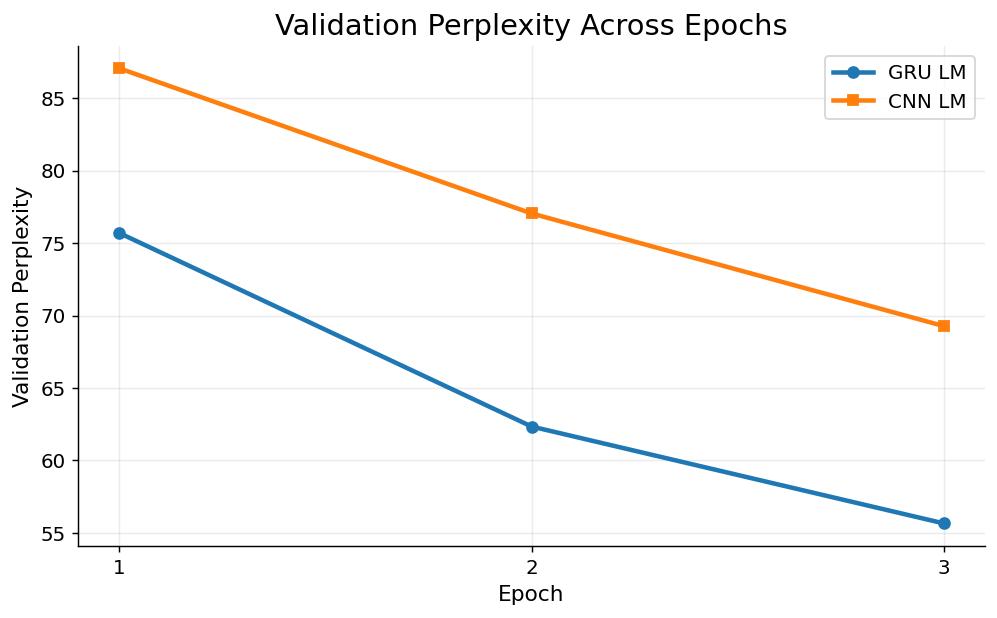

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    gru_history["epoch"],
    gru_history["val_perplexity"],
    marker="o",
    linewidth=2.5,
    label="GRU LM"
)

ax.plot(
    cnn_history["epoch"],
    cnn_history["val_perplexity"],
    marker="s",
    linewidth=2.5,
    label="CNN LM"
)

ax.set_title("Validation Perplexity Across Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Perplexity")
ax.set_xticks(gru_history["epoch"])
ax.legend(frameon=True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig(f"{FIG_DIR}/val_perplexity_curves.png")
plt.show()

## Plot 3 - Train vs validation loss

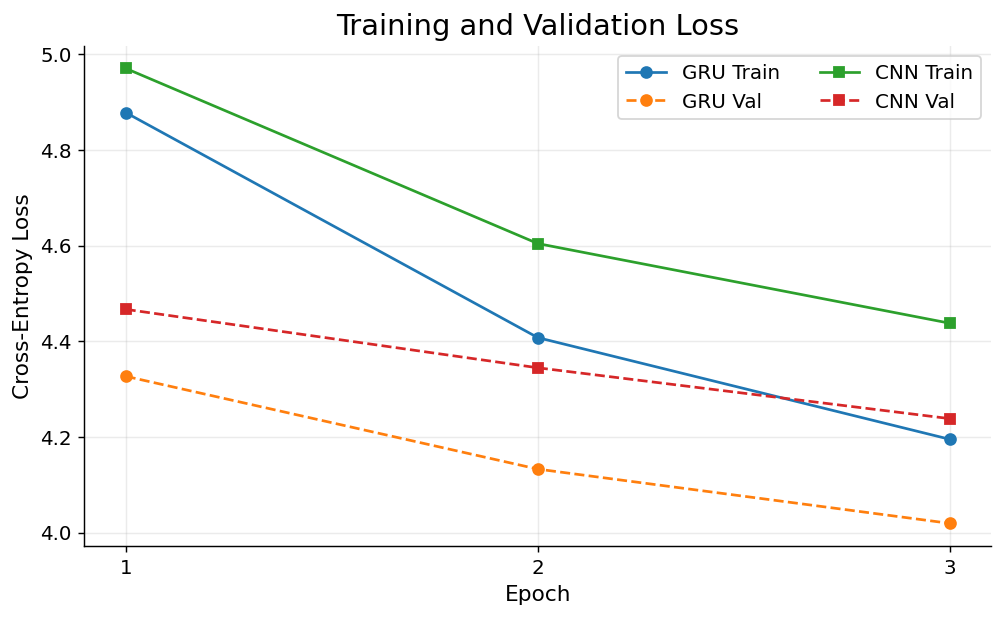

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(gru_history["epoch"], gru_history["train_loss"], marker="o", linestyle="-", label="GRU Train")
ax.plot(gru_history["epoch"], gru_history["val_loss"], marker="o", linestyle="--", label="GRU Val")

ax.plot(cnn_history["epoch"], cnn_history["train_loss"], marker="s", linestyle="-", label="CNN Train")
ax.plot(cnn_history["epoch"], cnn_history["val_loss"], marker="s", linestyle="--", label="CNN Val")

ax.set_title("Training and Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_xticks(gru_history["epoch"])
ax.legend(ncol=2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig(f"{FIG_DIR}/train_val_loss_curves.png")
plt.show()

## Plot 4 - Switch accuracy comparison

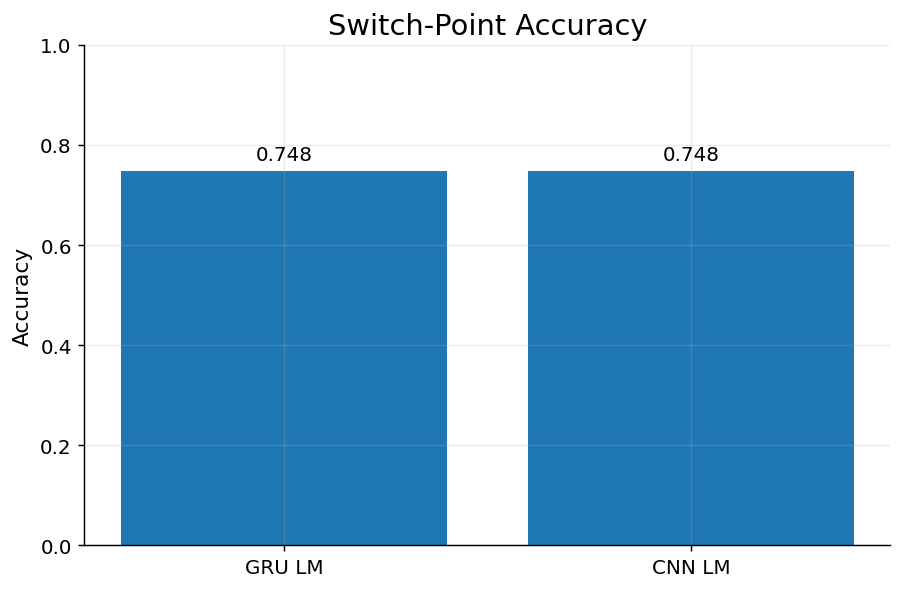

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

values = comparison_df["Switch Accuracy"]

bars = ax.bar(comparison_df["Model"], values)

ax.set_title("Switch-Point Accuracy")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.015,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig(f"{FIG_DIR}/switch_accuracy_bar.png")
plt.show()

## Plot 5 - Perplexity improvement over epochs

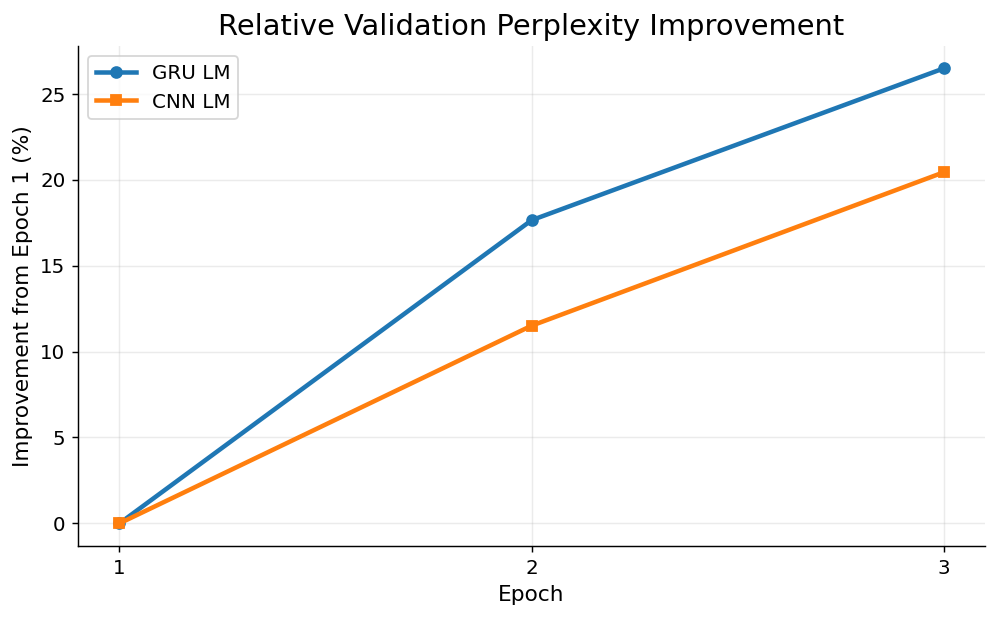

In [9]:
gru_start = gru_history["val_perplexity"].iloc[0]
cnn_start = cnn_history["val_perplexity"].iloc[0]

gru_improvement = (gru_start - gru_history["val_perplexity"]) / gru_start * 100
cnn_improvement = (cnn_start - cnn_history["val_perplexity"]) / cnn_start * 100

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(gru_history["epoch"], gru_improvement, marker="o", linewidth=2.5, label="GRU LM")
ax.plot(cnn_history["epoch"], cnn_improvement, marker="s", linewidth=2.5, label="CNN LM")

ax.set_title("Relative Validation Perplexity Improvement")
ax.set_xlabel("Epoch")
ax.set_ylabel("Improvement from Epoch 1 (%)")
ax.set_xticks(gru_history["epoch"])
ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig(f"{FIG_DIR}/relative_perplexity_improvement.png")
plt.show()

## Plot 6 - Final metric radar-style plot

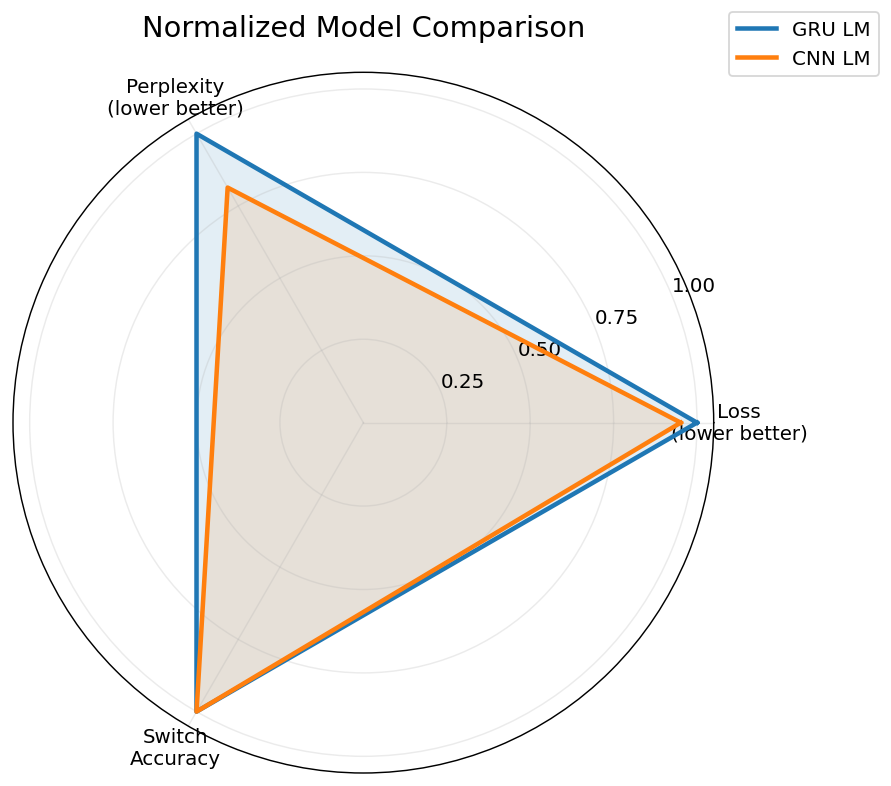

In [10]:
radar_df = comparison_df.copy()

# Convert metrics so higher is better
radar_df["Inverse Loss"] = 1 / radar_df["Test Loss"]
radar_df["Inverse Perplexity"] = 1 / radar_df["Test Perplexity"]
radar_df["Switch Accuracy"] = radar_df["Switch Accuracy"]

metrics = ["Inverse Loss", "Inverse Perplexity", "Switch Accuracy"]

# normalize each metric to 0-1
normalized = radar_df[metrics].copy()
for col in metrics:
    normalized[col] = normalized[col] / normalized[col].max()

labels = ["Loss\n(lower better)", "Perplexity\n(lower better)", "Switch\nAccuracy"]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

for idx, model_name in enumerate(radar_df["Model"]):
    values = normalized.iloc[idx].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2.5, label=model_name)
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_ylim(0, 1.05)

ax.set_title("Normalized Model Comparison", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))

plt.savefig(f"{FIG_DIR}/model_radar_comparison.png")
plt.show()

## Plot 7 - Summary table as image

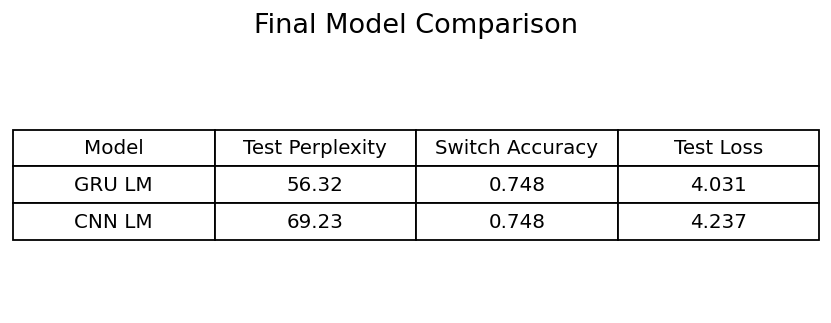

In [11]:
display_df = comparison_df[["Model", "Test Perplexity", "Switch Accuracy", "Test Loss"]].copy()
display_df["Test Perplexity"] = display_df["Test Perplexity"].round(2)
display_df["Switch Accuracy"] = display_df["Switch Accuracy"].round(3)
display_df["Test Loss"] = display_df["Test Loss"].round(3)

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis("off")

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.7)

ax.set_title("Final Model Comparison", fontsize=15, pad=15)

plt.savefig(f"{FIG_DIR}/comparison_table.png")
plt.show()

## Main Findings

The GRU language model achieved better next-token prediction than the CNN language model. Its test perplexity was 56.32, while the CNN reached 69.23. This suggests that the recurrent architecture handled the sequential structure of the Russian-English mixed text more effectively in this setup.

At the same time, both models achieved almost identical switch-point accuracy, around 0.748. This means that switch accuracy alone is not enough to evaluate switch prediction quality. The result probably reflects class imbalance, because most neighboring token pairs do not contain a language switch.

Overall, the GRU is the stronger language model baseline in this experiment, while switch-point prediction requires more detailed evaluation with precision, recall, and F1-score for the actual switch class.